# BENIN DATASET 

### Importing necessary packages

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

#### Importing the dataset using pandas read_csv method and saving it as 'data' and describing it using describe

In [108]:
data = pd.read_csv('benin-malanville.csv')
data.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


#### Checking whether the dataset has any null values in any column and summing them

In [109]:
data.isna().sum()


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

#### Identifying Columns with >5% Nulls

In [110]:
null_percent = data.isna().mean() * 100
print(null_percent[null_percent > 5])


Comments    100.0
dtype: float64


#### Outlier detection using z-score

In [111]:
numeric_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = np.abs(zscore(data[numeric_cols]))
outliers = (z_scores > 3)
df_outliers = data[(outliers).any(axis=1)]
df_outliers


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
670,2021-08-09 11:11,836.0,235.0,610.6,778.8,783.8,30.3,68.2,3.2,4.1,0.7,190.5,18.4,999,0,0.0,63.0,52.7,NaN
671,2021-08-09 11:12,1274.0,698.8,615.2,1210.3,1210.3,30.1,69.6,3.4,4.1,0.6,175.8,13.3,999,0,0.0,63.7,53.1,NaN
672,2021-08-09 11:13,938.0,340.1,612.8,891.1,891.1,30.4,68.4,3.4,4.6,0.9,171.5,11.9,999,0,0.0,65.8,54.3,NaN
673,2021-08-09 11:14,718.5,126.8,593.2,682.6,682.6,30.6,68.2,4.7,5.6,0.6,160.7,8.0,999,0,0.0,65.4,54.2,NaN
674,2021-08-09 11:15,1349.0,771.8,618.0,1281.5,1281.5,30.9,67.1,4.0,4.6,0.4,169.1,12.3,999,0,0.0,65.0,53.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
525141,2022-08-08 16:22,4.6,-0.1,4.6,6.1,5.9,21.9,99.0,7.1,9.7,1.2,127.8,10.7,995,0,0.2,22.8,22.0,NaN
525142,2022-08-08 16:23,4.6,0.2,4.6,5.9,5.8,21.9,99.0,6.5,9.2,1.2,126.3,12.3,995,0,0.2,22.8,22.0,NaN
525143,2022-08-08 16:24,4.5,-0.1,4.5,5.8,5.7,21.9,99.0,6.7,8.9,1.1,132.0,8.1,995,0,0.2,22.7,22.0,NaN
525151,2022-08-08 16:32,4.7,-0.1,4.8,6.0,5.9,22.0,99.1,7.3,8.7,0.8,146.9,8.8,995,0,0.1,22.8,22.0,NaN


#### Handling missing values

In [112]:
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())
data[numeric_cols]

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
0,-1.2,-0.2,-1.1,0.0,0.0,0.0,0.4
1,-1.1,-0.2,-1.1,0.0,0.0,0.0,0.0
2,-1.1,-0.2,-1.1,0.0,0.0,0.3,1.1
3,-1.1,-0.1,-1.0,0.0,0.0,0.2,0.7
4,-1.0,-0.1,-1.0,0.0,0.0,0.1,0.7
...,...,...,...,...,...,...,...
525595,-5.5,-0.1,-5.9,0.0,0.0,0.3,1.1
525596,-5.5,-0.1,-5.8,0.0,0.0,0.2,0.7
525597,-5.5,-0.1,-5.8,0.0,0.0,0.6,1.1
525598,-5.5,-0.1,-5.8,0.0,0.0,0.9,1.3


#### Dropped the "Comments" column because it has no values

In [113]:
data = data.drop(columns=['Comments'])
data.isna().sum()

Timestamp        0
GHI              0
DNI              0
DHI              0
ModA             0
ModB             0
Tamb             0
RH               0
WS               0
WSgust           0
WSstdev          0
WD               0
WDstdev          0
BP               0
Cleaning         0
Precipitation    0
TModA            0
TModB            0
dtype: int64

#### Export cleaned data

In [114]:
data.to_csv('benin_clean.csv', index=False)


#### Convert Timestamp Column to Datetime

In [115]:
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Timestamp']


0        2021-08-09 00:01:00
1        2021-08-09 00:02:00
2        2021-08-09 00:03:00
3        2021-08-09 00:04:00
4        2021-08-09 00:05:00
                 ...        
525595   2022-08-08 23:56:00
525596   2022-08-08 23:57:00
525597   2022-08-08 23:58:00
525598   2022-08-08 23:59:00
525599   2022-08-09 00:00:00
Name: Timestamp, Length: 525600, dtype: datetime64[ns]

#### Plotting time series as a loop

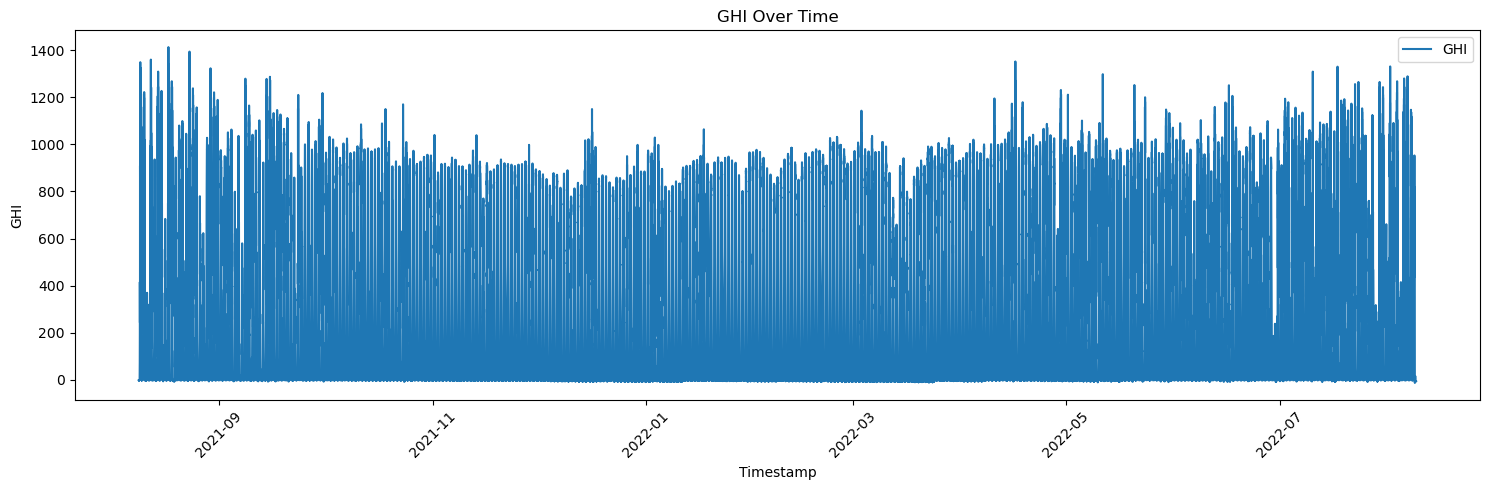

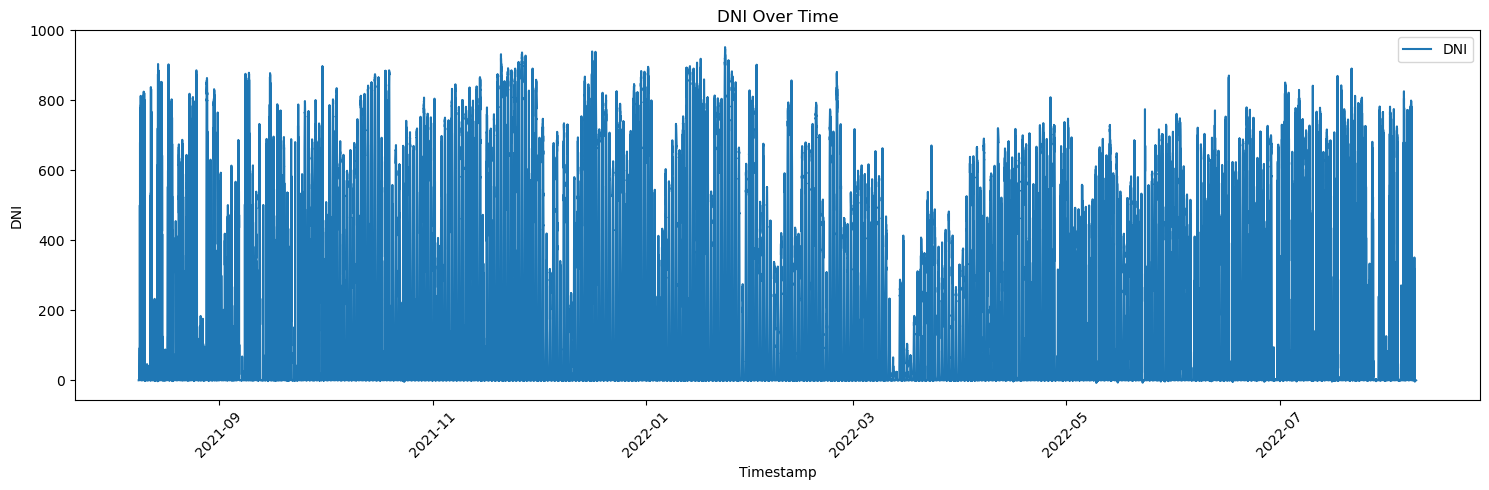

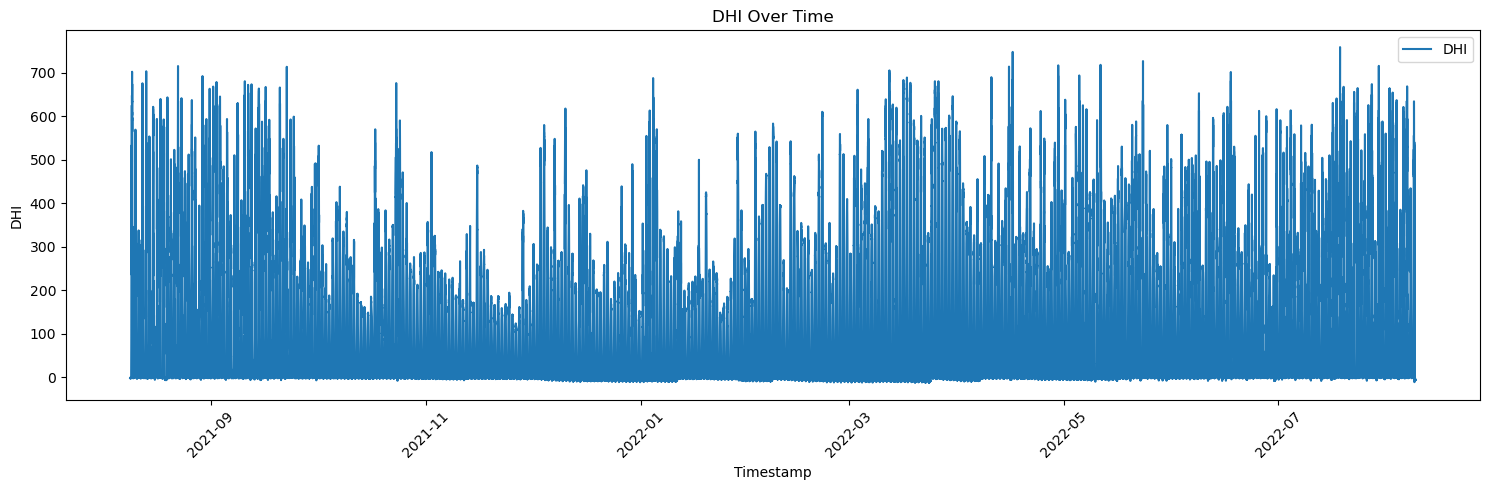

In [116]:
columns = ['GHI', 'DNI', 'DHI']
for col in columns:
    plt.figure(figsize=(15, 5))
    plt.plot(data['Timestamp'], data[col], label=col)
    plt.xlabel('Timestamp')
    plt.ylabel(col)
    plt.title(f'{col} Over Time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Plotting time series individually

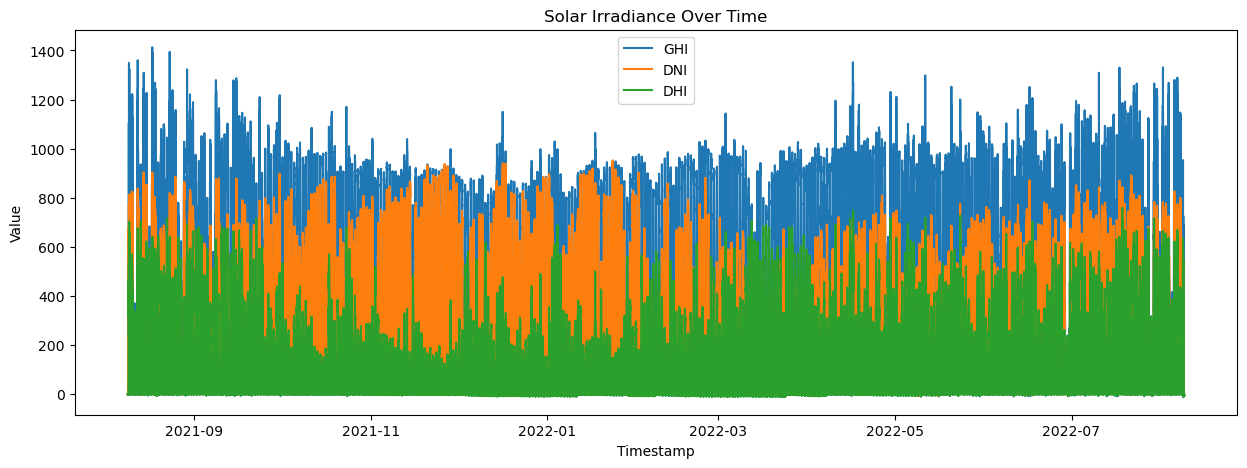

In [117]:
plt.figure(figsize=(15, 5))
plt.plot(data['Timestamp'], data['GHI'], label='GHI')
plt.plot(data['Timestamp'], data['DNI'], label='DNI')
plt.plot(data['Timestamp'], data['DHI'], label='DHI')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Solar Irradiance Over Time')
plt.legend()
plt.show()

#### Barplot

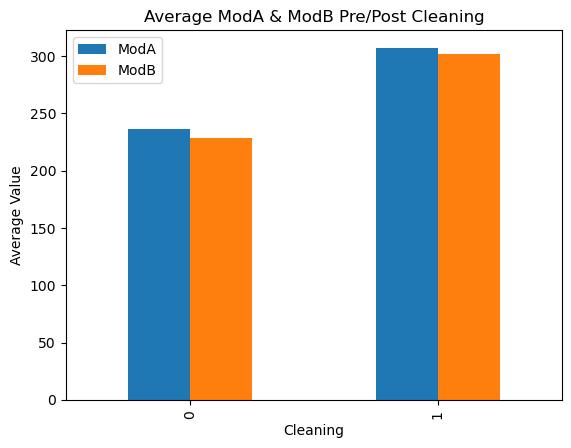

In [118]:
data.groupby('Cleaning')[['ModA', 'ModB']].mean().plot(kind='bar')
plt.title('Average ModA & ModB Pre/Post Cleaning')
plt.ylabel('Average Value')
plt.show()


#### Correlation Heatmap

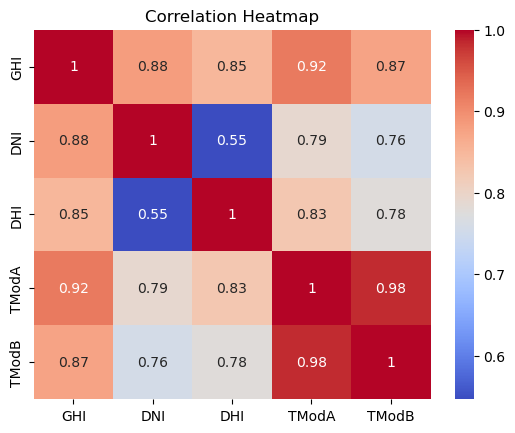

In [119]:
corr = data[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


#### Scatter plots

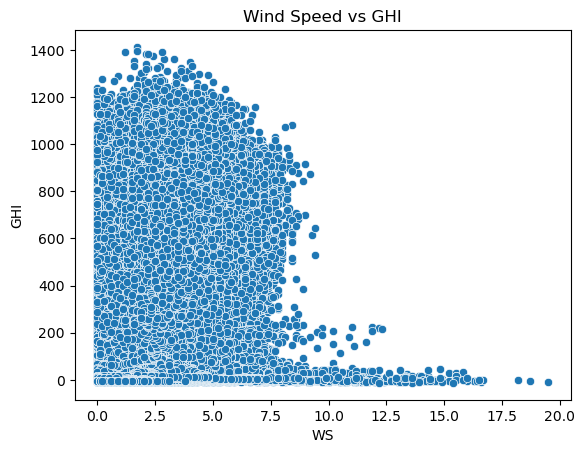

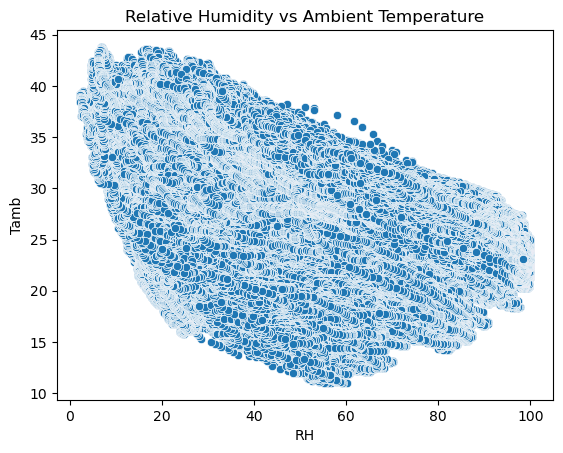

In [120]:
sns.scatterplot(data=data, x='WS', y='GHI')
plt.title('Wind Speed vs GHI')
plt.show()

sns.scatterplot(data=data, x='RH', y='Tamb')
plt.title('Relative Humidity vs Ambient Temperature')
plt.show()


#### Histogram for GHI

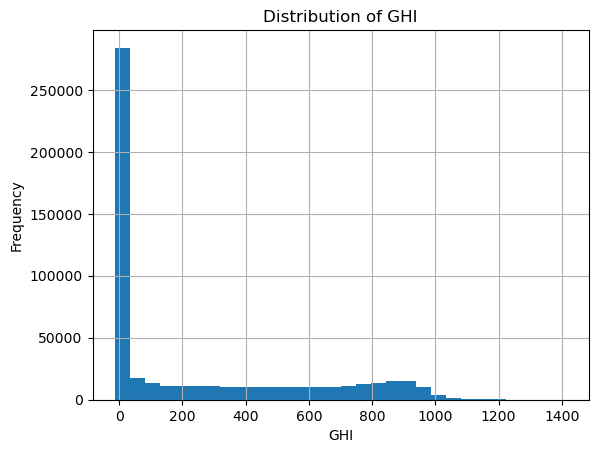

In [121]:
data['GHI'].hist(bins=30)
plt.title('Distribution of GHI')
plt.xlabel('GHI')
plt.ylabel('Frequency')
plt.show()


#### Histogram for WS

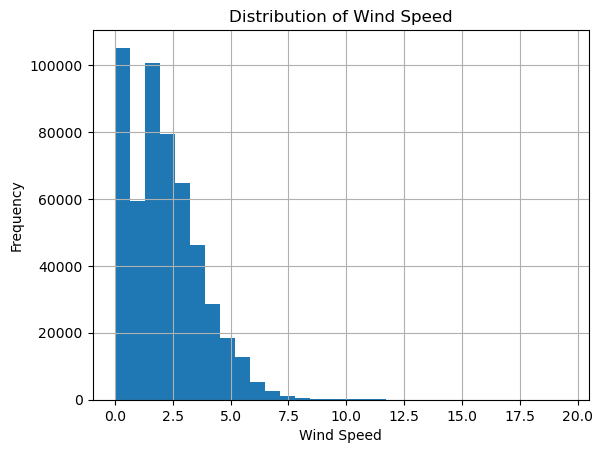

In [122]:
data['WS'].hist(bins=30)
plt.title('Distribution of Wind Speed')
plt.xlabel('Wind Speed')
plt.ylabel('Frequency')
plt.show()


#### Bubble Chart: GHI vs Tamb with RH as Size for temprature analysis

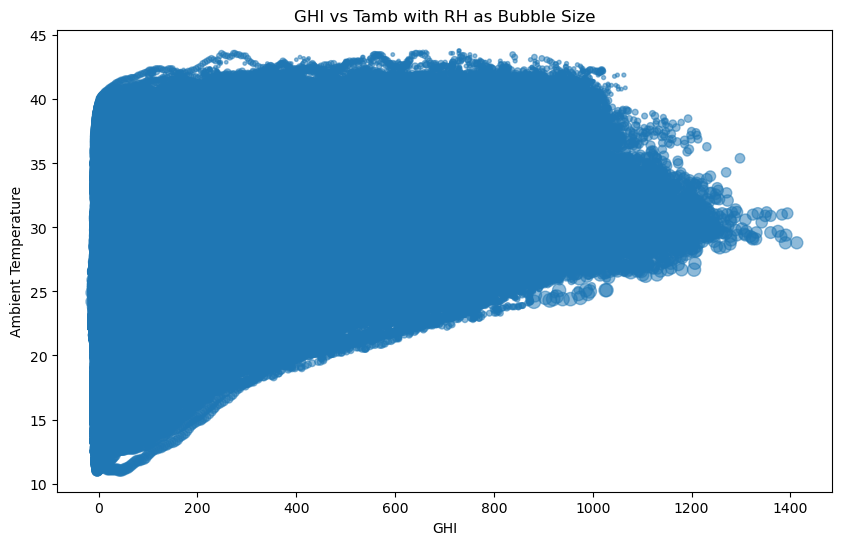

In [123]:
plt.figure(figsize=(10, 6))
plt.scatter(data['GHI'], data['Tamb'], s=data['RH'], alpha=0.5)
plt.xlabel('GHI')
plt.ylabel('Ambient Temperature')
plt.title('GHI vs Tamb with RH as Bubble Size')
plt.show()
